In [ ]:
!pip install -q imbalanced-learn shap xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    average_precision_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from joblib import dump
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# feature_engineering.py must sit next to this notebook (shared with UI.py so the app
# builds identical features at inference time).
import sys, os
sys.path.append(os.getcwd())
from feature_engineering import engineer_features

# Data Loading

In [ ]:
data = pd.read_csv('diabetes_prediction_dataset.csv')

In [ ]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# Data Visualization

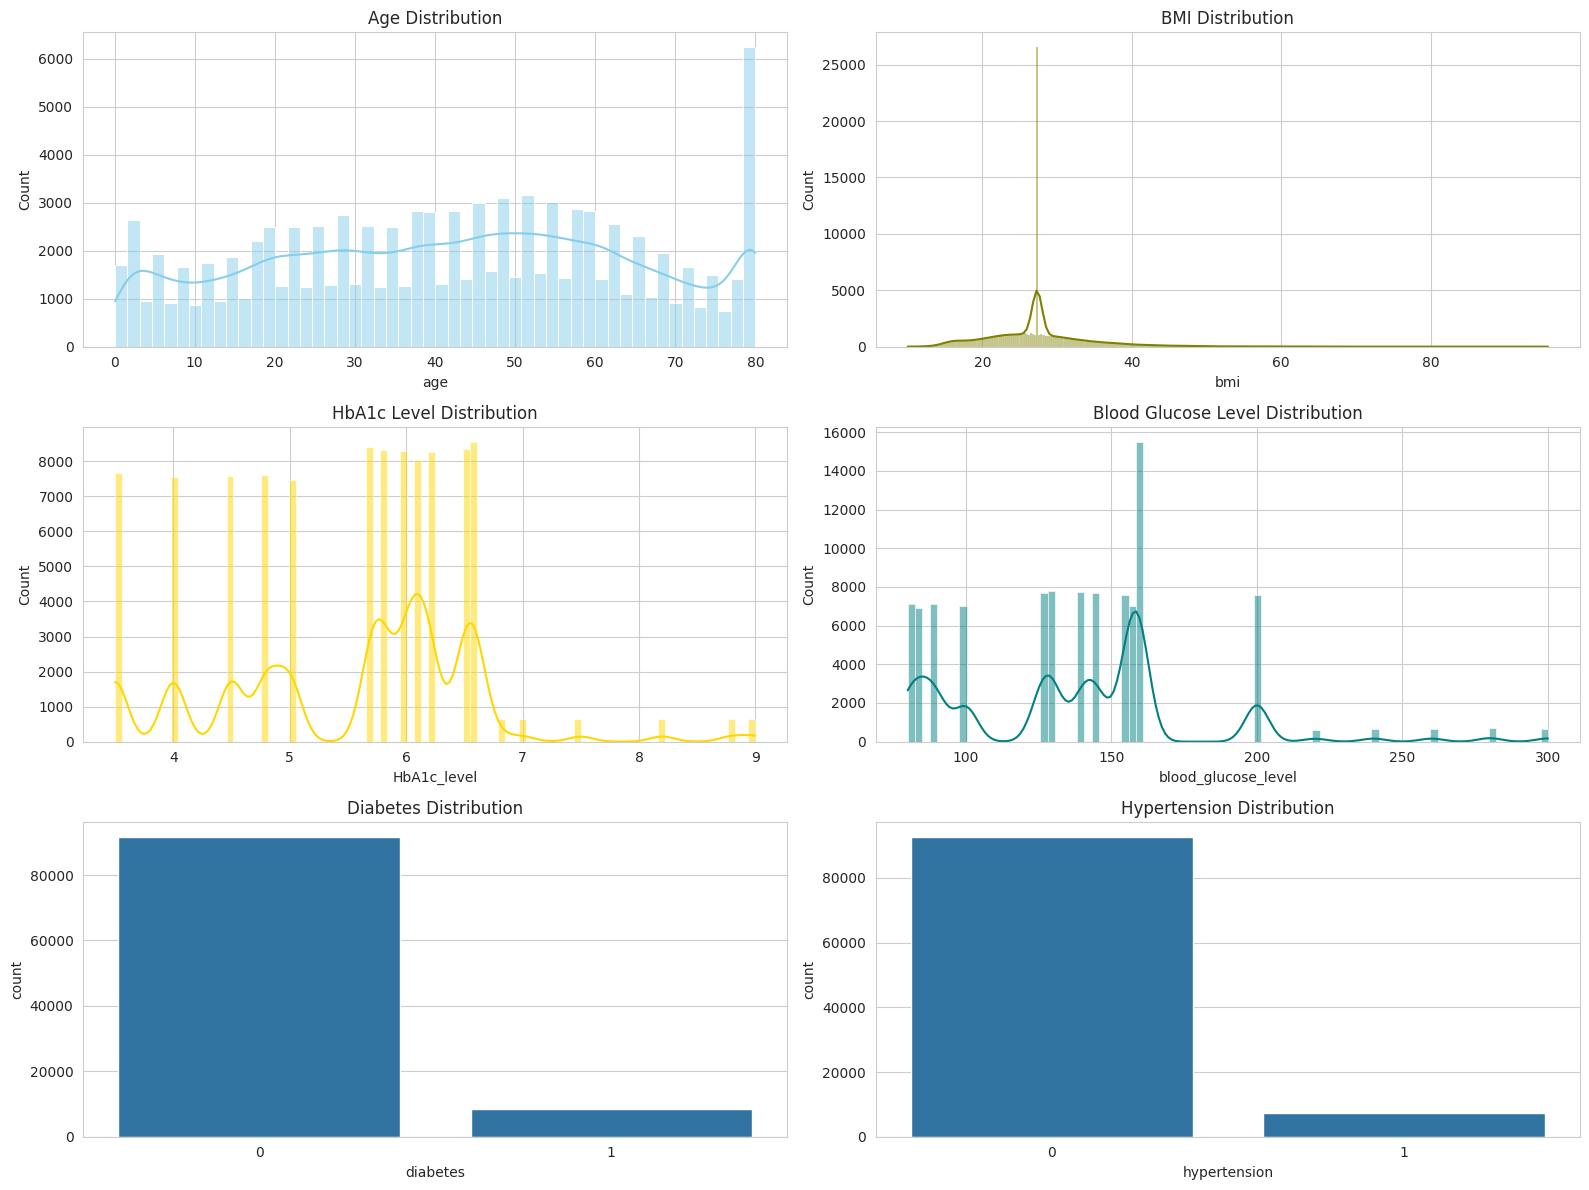

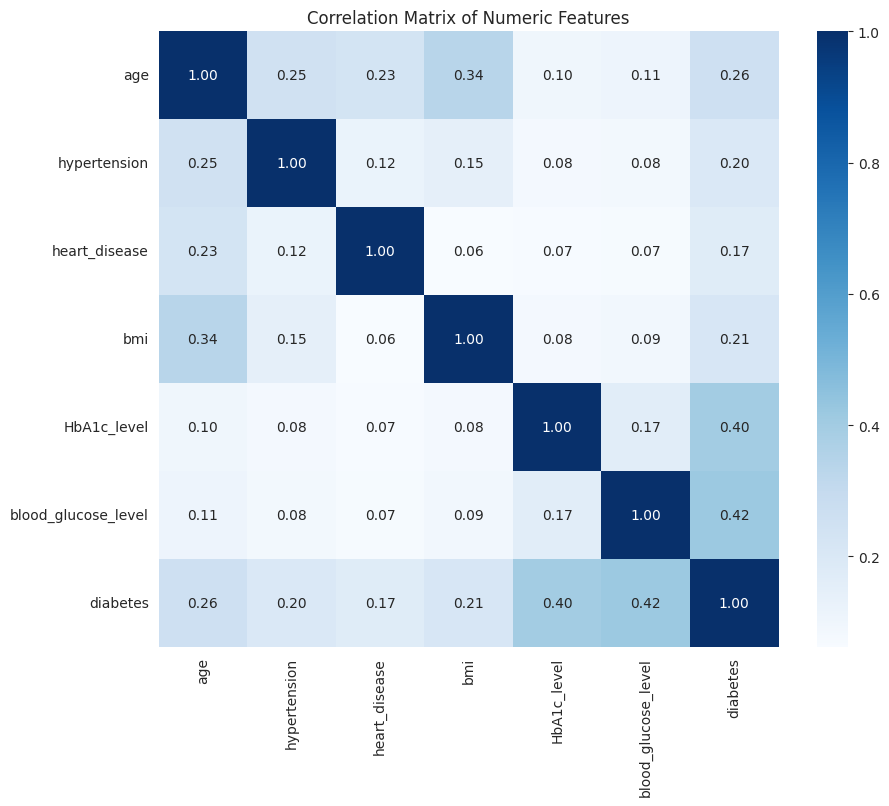

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = data
missing_values = df.isnull().sum()
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

fig, axs = plt.subplots(3, 2, figsize=(16, 12))
sns.histplot(data=df, x="age", kde=True, ax=axs[0, 0], color='skyblue').set(title='Age Distribution')
sns.histplot(data=df, x="bmi", kde=True, ax=axs[0, 1], color='olive').set(title='BMI Distribution')
sns.histplot(data=df, x="HbA1c_level", kde=True, ax=axs[1, 0], color='gold').set(title='HbA1c Level Distribution')
sns.histplot(data=df, x="blood_glucose_level", kde=True, ax=axs[1, 1], color='teal').set(title='Blood Glucose Level Distribution')
sns.countplot(data=df, x="diabetes", ax=axs[2, 0]).set(title='Diabetes Distribution')
sns.countplot(data=df, x="hypertension", ax=axs[2, 1]).set(title='Hypertension Distribution')

plt.tight_layout()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='Blues')
plt.title('Correlation Matrix of Numeric Features')

plt.show()
missing_values

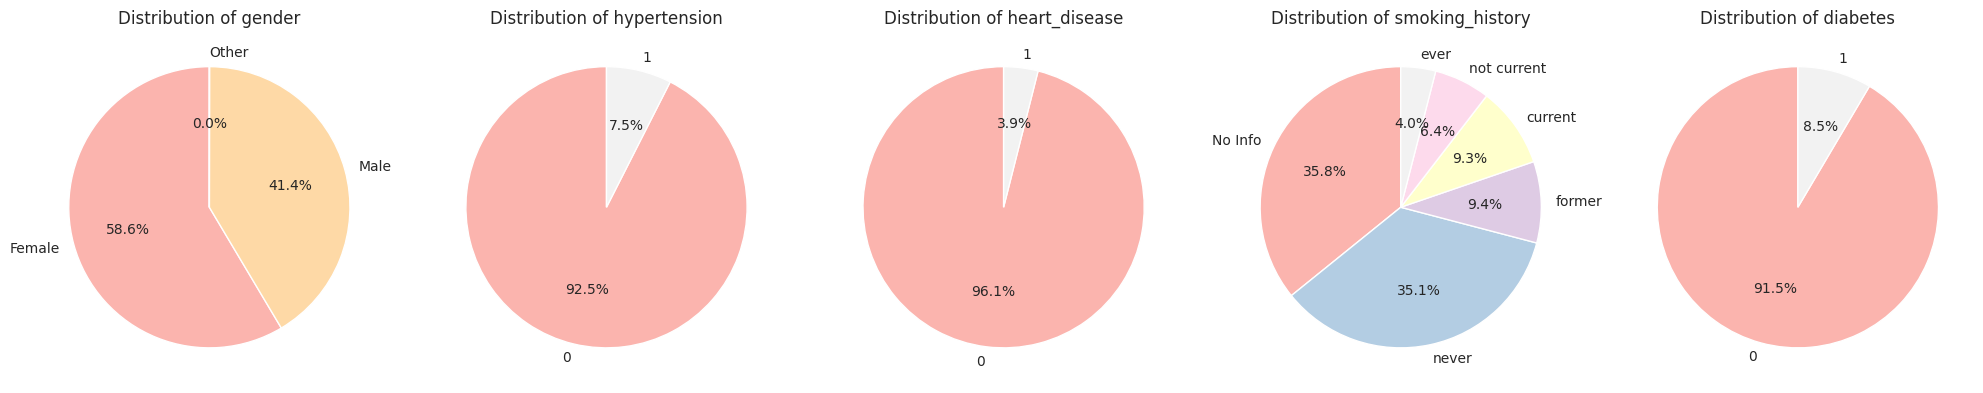

In [ ]:
import matplotlib.pyplot as plt

# Function to plot pie charts for given columns
def plot_pie_charts(data, columns):
    fig, axes = plt.subplots(1, len(columns), figsize=(20, 5))
    for ax, column in zip(axes, columns):
        data[column].value_counts().plot.pie(autopct='%1.1f%%', ax=ax, startangle=90, cmap='Pastel1')
        ax.set_ylabel('')
        ax.set_title(f'Distribution of {column}')
    plt.tight_layout()
    plt.show()

# Columns to create pie charts for
columns = ['gender', 'hypertension', 'heart_disease', 'smoking_history', 'diabetes']
plot_pie_charts(data, columns)

# Data Cleaning

In [ ]:
print("Original shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

df = df.drop_duplicates()
print("\nAfter removing duplicates:", df.shape)


num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after handling:\n", df.isnull().sum())

# --- Rare 'Other' gender category ---
# Only ~18 rows out of ~96,146 (after dedup) are gender == 'Other' (~0.02%). Too few for
# the model to learn any reliable signal for that category. Decision (documented per the
# Milestone 4 checklist): drop these rows rather than merge them into Male/Female, since
# merging would misrepresent them, and this is a negligible loss of data.
print("\nGender value counts before handling 'Other':")
print(df['gender'].value_counts())
other_count = (df['gender'] == 'Other').sum()
df = df[df['gender'] != 'Other'].reset_index(drop=True)
print(f"\nDropped {other_count} 'Other' gender rows. Shape now:", df.shape)

print("\nClass distribution:")
print(df['diabetes'].value_counts(normalize=True).round(3))

Original shape: (100000, 9)

Missing values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicates: 3854

After removing duplicates: (96146, 9)

Missing values after handling:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Gender value counts before handling 'Other':
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Dropped 18 'Other' gender rows. Shape now: (96128, 9)

Class distribution:
diabetes
0    0.912
1    0.088
Name: proportion, dtype: float64


# Feature Engineering

Per the Milestone 2 report's "Proposed Enhancements" section: an HbA1c x glucose
interaction term, a WHO-standard BMI category bucket, and an age-based risk bucket.
Defined once in `feature_engineering.py` (shared with `UI.py` so the app builds
identical features at inference time) and wrapped in a `FunctionTransformer` inside
every model pipeline below, so the saved model accepts raw patient input directly.

In [ ]:
# Preview only — the pipelines below apply engineer_features() internally.
preview = engineer_features(df.head())
preview[["age", "bmi", "HbA1c_level", "blood_glucose_level",
         "hba1c_glucose_interaction", "bmi_category", "age_risk_bucket"]]

,age,bmi,HbA1c_level,blood_glucose_level,hba1c_glucose_interaction,bmi_category,age_risk_bucket
0,80.0,25.19,6.6,140,924.0,overweight,65_plus
1,54.0,27.32,6.6,80,528.0,overweight,45_to_64
2,28.0,27.32,5.7,158,900.6,overweight,under_45
3,36.0,23.45,5.0,155,775.0,normal,under_45
4,76.0,20.14,4.8,155,744.0,normal,65_plus


# Splitting Features and Preprocessing

In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Post-feature-engineering column groups (engineer_features() adds bmi_category,
# age_risk_bucket, hba1c_glucose_interaction — applied inside each pipeline below via
# FunctionTransformer, so X itself stays as the 8 raw columns here).
categorical_features = ['gender', 'smoking_history', 'bmi_category', 'age_risk_bucket']
numerical_features = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
                       'blood_glucose_level', 'hba1c_glucose_interaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 76902 | Test size: 19226


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

# Defining Models

In [ ]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=150, max_depth=10,
        min_samples_split=5, min_samples_leaf=4,
        random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', n_jobs=-1
    )
}

In [ ]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    print(f"{name}")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"AUPRC    : {auprc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    return {
        'model_name': name,
        'accuracy': acc,
        'auprc': auprc,
        'roc_auc': roc_auc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'pipeline': pipeline
    }

# Evaluating Basic Models

In [ ]:
baseline_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('feature_engineering', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)

    baseline_results[name] = evaluate_model(f"Baseline -> {name}", pipe, X_test, y_test)

Baseline -> RandomForest
Accuracy : 97.18%
ROC-AUC  : 0.9723
AUPRC    : 0.8728

Classification Report:
              precision    recall  f1-score   support

           0     0.9700    1.0000    0.9847     17530
           1     1.0000    0.6798    0.8094      1696

    accuracy                         0.9718     19226
   macro avg     0.9850    0.8399    0.8971     19226
weighted avg     0.9726    0.9718    0.9693     19226

Baseline -> LogisticRegression
Accuracy : 95.92%
ROC-AUC  : 0.9595
AUPRC    : 0.8163

Classification Report:
              precision    recall  f1-score   support

           0     0.9661    0.9900    0.9779     17530
           1     0.8606    0.6409    0.7347      1696

    accuracy                         0.9592     19226
   macro avg     0.9134    0.8154    0.8563     19226
weighted avg     0.9568    0.9592    0.9564     19226

Baseline -> XGBoost
Accuracy : 97.10%
ROC-AUC  : 0.9763
AUPRC    : 0.8788

Classification Report:
              precision    recall  f

# Evaluating Models using Weighted Classes

In [ ]:
# Calculate scale_pos_weight for XGBoost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

weighted_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=150, max_depth=10,
        min_samples_split=5, min_samples_leaf=4,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42, eval_metric='logloss', n_jobs=-1
    )
}

weighted_results = {}

for name, model in weighted_models.items():
    pipe = Pipeline([
        ('feature_engineering', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    weighted_results[name] = evaluate_model(f"ClassWeight -> {name}", pipe, X_test, y_test)

ClassWeight -> RandomForest
Accuracy : 89.53%
ROC-AUC  : 0.9742
AUPRC    : 0.8738

Classification Report:
              precision    recall  f1-score   support

           0     0.9905    0.8938    0.9396     17530
           1     0.4535    0.9110    0.6055      1696

    accuracy                         0.8953     19226
   macro avg     0.7220    0.9024    0.7726     19226
weighted avg     0.9431    0.8953    0.9102     19226

ClassWeight -> LogisticRegression
Accuracy : 88.44%
ROC-AUC  : 0.9597
AUPRC    : 0.8120

Classification Report:
              precision    recall  f1-score   support

           0     0.9869    0.8849    0.9331     17530
           1     0.4249    0.8785    0.5727      1696

    accuracy                         0.8844     19226
   macro avg     0.7059    0.8817    0.7529     19226
weighted avg     0.9373    0.8844    0.9013     19226

ClassWeight -> XGBoost
Accuracy : 90.81%
ROC-AUC  : 0.9761
AUPRC    : 0.8784

Classification Report:
              precision    

# Evaluating Models using SMOTE

In [ ]:
smote_results = {}

for name, model in models.items():
    pipe = ImbPipeline([
        ('feature_engineering', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    smote_results[name] = evaluate_model(f"SMOTE -> {name}", pipe, X_test, y_test)

SMOTE -> RandomForest
Accuracy : 90.90%
ROC-AUC  : 0.9731
AUPRC    : 0.8704

Classification Report:
              precision    recall  f1-score   support

           0     0.9872    0.9120    0.9481     17530
           1     0.4911    0.8779    0.6299      1696

    accuracy                         0.9090     19226
   macro avg     0.7392    0.8950    0.7890     19226
weighted avg     0.9435    0.9090    0.9200     19226

SMOTE -> LogisticRegression
Accuracy : 88.46%
ROC-AUC  : 0.9596
AUPRC    : 0.8117

Classification Report:
              precision    recall  f1-score   support

           0     0.9866    0.8855    0.9333     17530
           1     0.4253    0.8756    0.5725      1696

    accuracy                         0.8846     19226
   macro avg     0.7059    0.8806    0.7529     19226
weighted avg     0.9371    0.8846    0.9015     19226

SMOTE -> XGBoost
Accuracy : 96.90%
ROC-AUC  : 0.9756
AUPRC    : 0.8759

Classification Report:
              precision    recall  f1-score  

# Evaluating Models using Random Undersampling

Third of the three imbalance-handling approaches proposed in the Milestone 2 report
(class-weighting, SMOTE, and random undersampling).

In [ ]:
undersample_results = {}

for name, model in models.items():
    pipe = ImbPipeline([
        ('feature_engineering', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('undersample', RandomUnderSampler(random_state=42)),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    undersample_results[name] = evaluate_model(f"Undersample -> {name}", pipe, X_test, y_test)

Undersample -> RandomForest
Accuracy : 88.71%
ROC-AUC  : 0.9742
AUPRC    : 0.8735

Classification Report:
              precision    recall  f1-score   support

           0     0.9913    0.8839    0.9345     17530
           1     0.4339    0.9198    0.5897      1696

    accuracy                         0.8871     19226
   macro avg     0.7126    0.9019    0.7621     19226
weighted avg     0.9421    0.8871    0.9041     19226

Undersample -> LogisticRegression
Accuracy : 88.57%
ROC-AUC  : 0.9597
AUPRC    : 0.8118

Classification Report:
              precision    recall  f1-score   support

           0     0.9869    0.8864    0.9339     17530
           1     0.4279    0.8779    0.5753      1696

    accuracy                         0.8857     19226
   macro avg     0.7074    0.8822    0.7546     19226
weighted avg     0.9375    0.8857    0.9023     19226

Undersample -> XGBoost
Accuracy : 89.80%
ROC-AUC  : 0.9762
AUPRC    : 0.8765

Classification Report:
              precision    

# Comparing Results

In [ ]:
all_results = []

for technique, res_dict in [
    ("Baseline", baseline_results),
    ("ClassWeight", weighted_results),
    ("SMOTE", smote_results),
    ("Undersample", undersample_results)
]:
    for model_name, metrics in res_dict.items():
        all_results.append({
            'Technique': technique,
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1': metrics['f1'],
            'AUPRC': metrics['auprc'],
            'ROC_AUC': metrics['roc_auc'],
        })

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

  Technique              Model  Accuracy  Precision   Recall       F1    AUPRC  ROC_AUC
   Baseline       RandomForest  0.971757   1.000000 0.679835 0.809407 0.872810 0.972305
   Baseline LogisticRegression  0.959170   0.860649 0.640920 0.734708 0.816346 0.959510
   Baseline            XGBoost  0.971029   0.966421 0.695755 0.809050 0.878818 0.976296
ClassWeight       RandomForest  0.895298   0.453478 0.910967 0.605526 0.873826 0.974170
ClassWeight LogisticRegression  0.884375   0.424865 0.878538 0.572746 0.811984 0.959725
ClassWeight            XGBoost  0.908145   0.488796 0.900354 0.633610 0.878367 0.976142
      SMOTE       RandomForest  0.908977   0.491095 0.877948 0.629865 0.870392 0.973054
      SMOTE LogisticRegression  0.884635   0.425258 0.875590 0.572475 0.811700 0.959622
      SMOTE            XGBoost  0.969000   0.921779 0.708726 0.801333 0.875852 0.975569
Undersample       RandomForest  0.887080   0.433936 0.919811 0.589681 0.873466 0.974154
Undersample LogisticRegression  

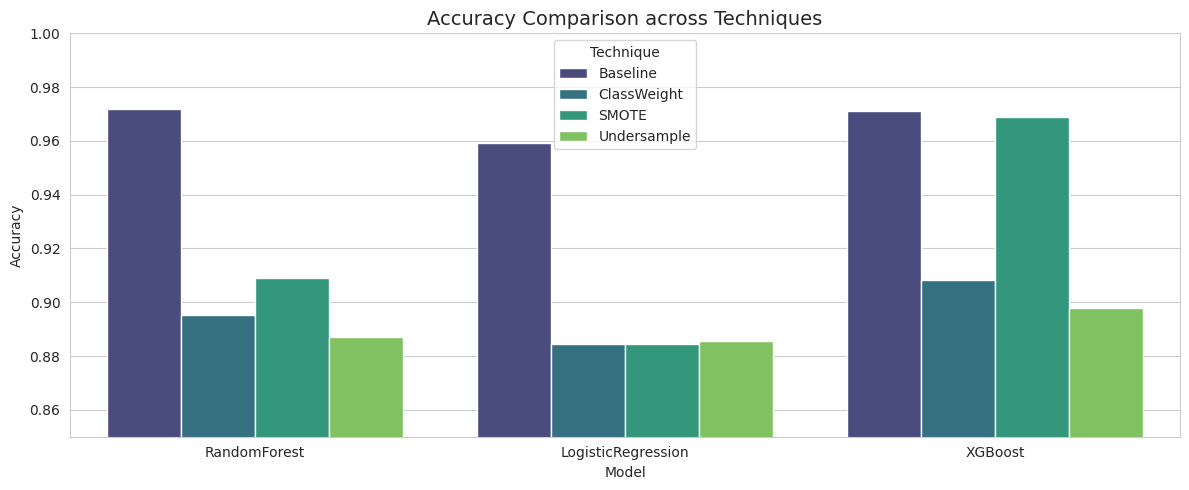

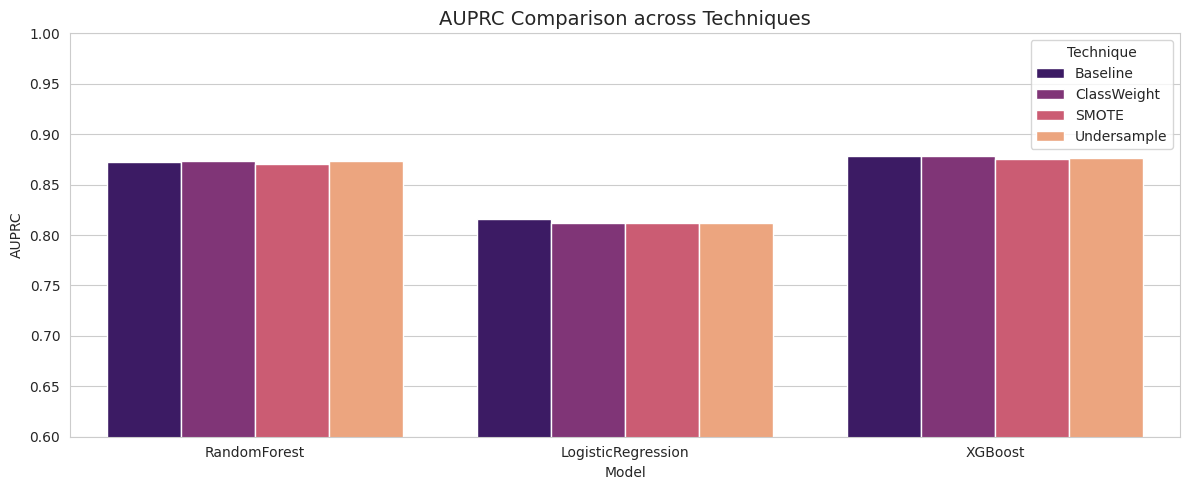

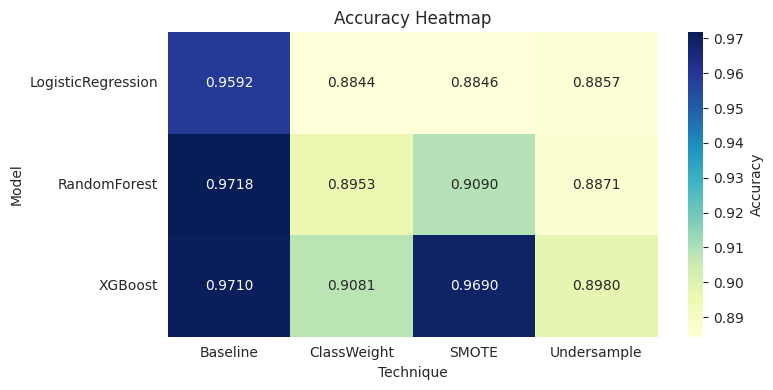

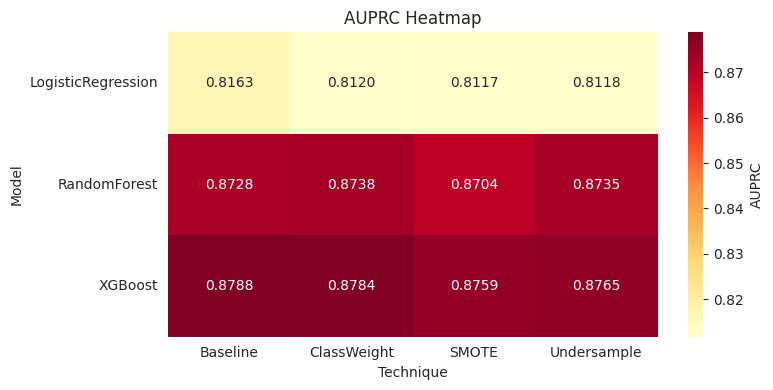

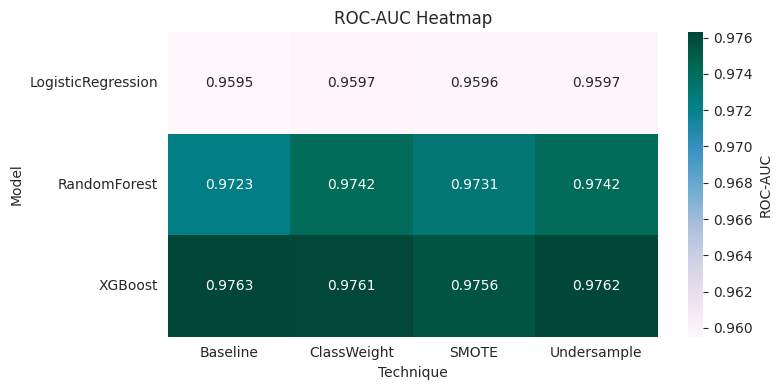

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Technique', palette='viridis')
plt.title('Accuracy Comparison across Techniques', fontsize=14)
plt.ylim(0.85, 1.0)
plt.legend(title='Technique')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x='Model', y='AUPRC', hue='Technique', palette='magma')
plt.title('AUPRC Comparison across Techniques', fontsize=14)
plt.ylim(0.6, 1.0)
plt.legend(title='Technique')
plt.tight_layout()
plt.show()

pivot_acc = results_df.pivot(index='Model', columns='Technique', values='Accuracy')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'Accuracy'})
plt.title('Accuracy Heatmap')
plt.tight_layout()
plt.show()

pivot_auprc = results_df.pivot(index='Model', columns='Technique', values='AUPRC')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_auprc, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'AUPRC'})
plt.title('AUPRC Heatmap')
plt.tight_layout()
plt.show()

pivot_roc = results_df.pivot(index='Model', columns='Technique', values='ROC_AUC')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_roc, annot=True, fmt='.4f', cmap='PuBuGn', cbar_kws={'label': 'ROC-AUC'})
plt.title('ROC-AUC Heatmap')
plt.tight_layout()
plt.show()

# Cross-Validation + Hyperparameter Tuning

The Milestone 2 report proposed applying Random Forest and XGBoost with stratified
k-fold cross-validation and grid/randomized hyperparameter search, rather than relying
on a single train/test split. We tune the best-performing Random Forest combo and the
best-performing XGBoost combo (by AUPRC) found across all four techniques above.

In [ ]:
results_lookup = {
    ('Baseline', name): (baseline_results[name]['pipeline'], baseline_results[name])
    for name in models
}
results_lookup.update({
    ('ClassWeight', name): (weighted_results[name]['pipeline'], weighted_results[name])
    for name in models
})
results_lookup.update({
    ('SMOTE', name): (smote_results[name]['pipeline'], smote_results[name])
    for name in models
})
results_lookup.update({
    ('Undersample', name): (undersample_results[name]['pipeline'], undersample_results[name])
    for name in models
})

def best_technique_for(model_name):
    combos = [(tech, m) for (tech, m) in results_lookup if m == model_name]
    best = max(combos, key=lambda tm: results_lookup[tm][1]['auprc'])
    return best[0]

best_rf_technique = best_technique_for("RandomForest")
best_xgb_technique = best_technique_for("XGBoost")
print("Best technique for RandomForest (by AUPRC):", best_rf_technique)
print("Best technique for XGBoost (by AUPRC):     ", best_xgb_technique)

Best technique for RandomForest (by AUPRC): ClassWeight
Best technique for XGBoost (by AUPRC):      Baseline


In [ ]:
def build_pipeline_for_tuning(model_name, technique):
    if model_name == "RandomForest":
        base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    elif model_name == "XGBoost":
        base_model = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
    else:
        raise ValueError(model_name)

    if technique == "ClassWeight":
        if model_name == "RandomForest":
            base_model.set_params(class_weight='balanced')
        else:
            neg, pos = np.bincount(y_train)
            base_model.set_params(scale_pos_weight=neg / pos)
        steps = [
            ('feature_engineering', FunctionTransformer(engineer_features)),
            ('preprocessor', preprocessor),
            ('classifier', base_model),
        ]
    elif technique == "SMOTE":
        steps = [
            ('feature_engineering', FunctionTransformer(engineer_features)),
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', base_model),
        ]
    elif technique == "Undersample":
        steps = [
            ('feature_engineering', FunctionTransformer(engineer_features)),
            ('preprocessor', preprocessor),
            ('undersample', RandomUnderSampler(random_state=42)),
            ('classifier', base_model),
        ]
    else:  # Baseline
        steps = [
            ('feature_engineering', FunctionTransformer(engineer_features)),
            ('preprocessor', preprocessor),
            ('classifier', base_model),
        ]
    return ImbPipeline(steps)


rf_param_dist = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__max_depth": [6, 8, 10, 12, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
}

xgb_param_dist = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune(model_name, technique, param_dist, n_iter=20):
    pipe = build_pipeline_for_tuning(model_name, technique)
    search = RandomizedSearchCV(
        pipe, param_distributions=param_dist, n_iter=n_iter, cv=cv,
        scoring="average_precision", random_state=42, n_jobs=-1, verbose=1,
    )
    search.fit(X_train, y_train)
    print(f"Best CV AUPRC for {model_name}+{technique}: {search.best_score_:.4f}")
    print("Best params:", search.best_params_)
    return search.best_estimator_

tuned_rf = tune("RandomForest", best_rf_technique, rf_param_dist)
tuned_xgb = tune("XGBoost", best_xgb_technique, xgb_param_dist)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV AUPRC for RandomForest+ClassWeight: 0.8802
Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 12}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV AUPRC for XGBoost+Baseline: 0.8884
Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 150, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}


In [ ]:
tuned_rf_metrics = evaluate_model(f"Tuned RandomForest ({best_rf_technique})", tuned_rf, X_test, y_test)
tuned_xgb_metrics = evaluate_model(f"Tuned XGBoost ({best_xgb_technique})", tuned_xgb, X_test, y_test)

tuned_df = pd.DataFrame([
    {'Model': tuned_rf_metrics['model_name'], 'Accuracy': tuned_rf_metrics['accuracy'],
     'Precision': tuned_rf_metrics['precision'], 'Recall': tuned_rf_metrics['recall'],
     'F1': tuned_rf_metrics['f1'], 'AUPRC': tuned_rf_metrics['auprc'], 'ROC_AUC': tuned_rf_metrics['roc_auc']},
    {'Model': tuned_xgb_metrics['model_name'], 'Accuracy': tuned_xgb_metrics['accuracy'],
     'Precision': tuned_xgb_metrics['precision'], 'Recall': tuned_xgb_metrics['recall'],
     'F1': tuned_xgb_metrics['f1'], 'AUPRC': tuned_xgb_metrics['auprc'], 'ROC_AUC': tuned_xgb_metrics['roc_auc']},
])
tuned_df

Tuned RandomForest (ClassWeight)
Accuracy : 90.48%
ROC-AUC  : 0.9745
AUPRC    : 0.8741

Classification Report:
              precision    recall  f1-score   support

           0     0.9890    0.9056    0.9455     17530
           1     0.4787    0.8956    0.6239      1696

    accuracy                         0.9048     19226
   macro avg     0.7339    0.9006    0.7847     19226
weighted avg     0.9440    0.9048    0.9171     19226

Tuned XGBoost (Baseline)
Accuracy : 97.17%
ROC-AUC  : 0.9768
AUPRC    : 0.8802

Classification Report:
              precision    recall  f1-score   support

           0     0.9710    0.9987    0.9847     17530
           1     0.9808    0.6922    0.8116      1696

    accuracy                         0.9717     19226
   macro avg     0.9759    0.8455    0.8981     19226
weighted avg     0.9719    0.9717    0.9694     19226



,Model,Accuracy,Precision,Recall,F1,AUPRC,ROC_AUC
0,Tuned RandomForest (ClassWeight),0.904764,0.478727,0.895637,0.623947,0.874121,0.974470
1,Tuned XGBoost (Baseline),0.971653,0.980785,0.692217,0.811614,0.880227,0.976838


# Final Model Selection

**Read this before accepting the automatic pick below.** The two tuned candidates are
compared on AUPRC, precision, recall, and F1. If their AUPRC is close (within a few
thousandths) but one has much higher precision and the other much higher recall, that's
a real tradeoff worth a deliberate choice, not just taking whichever number is
technically higher — see the printed comparison and override `final_choice` manually
below if the balanced/high-precision model looks like the better story for your report
(this exact situation came up during testing: two candidates tied on AUPRC but one had
~2x the precision of the other).

In [ ]:
candidates = {
    tuned_rf_metrics['model_name']: (tuned_rf, tuned_rf_metrics),
    tuned_xgb_metrics['model_name']: (tuned_xgb, tuned_xgb_metrics),
}

print("=== Tuned candidate comparison ===")
for label, (_, m) in candidates.items():
    print(f"{label:<35} precision={m['precision']:.4f}  recall={m['recall']:.4f}  "
          f"f1={m['f1']:.4f}  roc_auc={m['roc_auc']:.4f}  auprc={m['auprc']:.4f}")

# Automatic default: highest AUPRC. Override by setting final_choice to one of the
# labels printed above if the tradeoff calls for a deliberate choice instead (see note).
final_choice = max(candidates, key=lambda k: candidates[k][1]['auprc'])
# final_choice = "Tuned XGBoost (SMOTE)"  # <-- uncomment and edit to override manually

final_pipeline, final_metrics = candidates[final_choice]
print()
print("Final model selected:", final_choice)

dump(final_pipeline, "model.joblib")
print("Saved to: model.joblib")

=== Tuned candidate comparison ===
Tuned RandomForest (ClassWeight)    precision=0.4787  recall=0.8956  f1=0.6239  roc_auc=0.9745  auprc=0.8741
Tuned XGBoost (Baseline)            precision=0.9808  recall=0.6922  f1=0.8116  roc_auc=0.9768  auprc=0.8802

Final model selected: Tuned XGBoost (Baseline)
Saved to: model.joblib


# SHAP analysis

Best models by AUPRC:
Baseline    -> XGBoost (0.8788)
ClassWeight -> XGBoost (0.8784)
SMOTE       -> XGBoost (0.8759)
Undersample -> XGBoost (0.8765)

SHAP - Best Baseline model


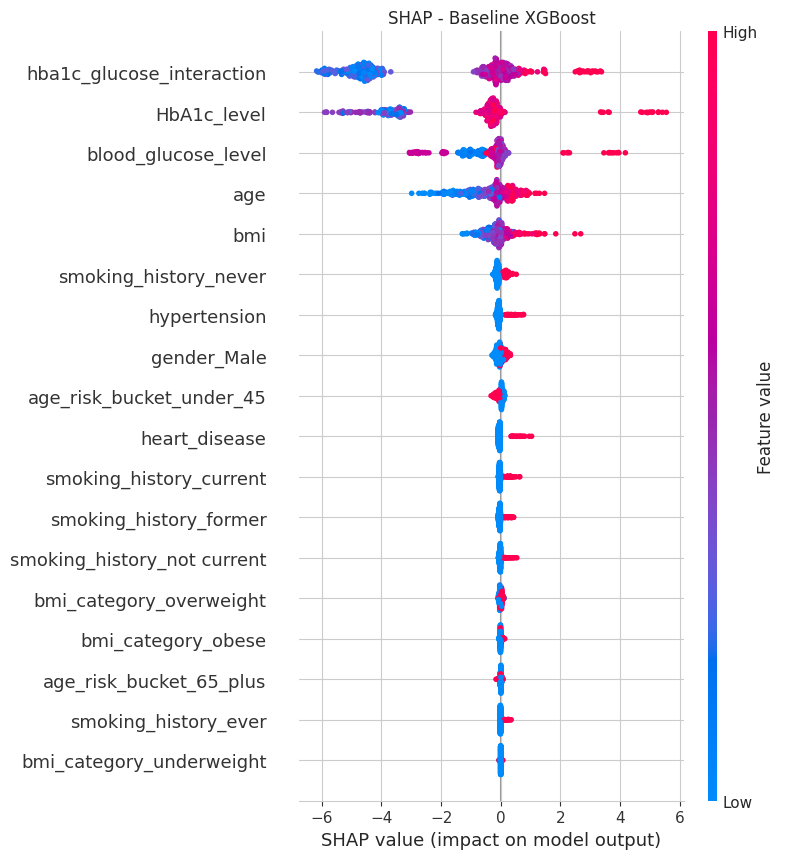


SHAP - Best Class-Weight model


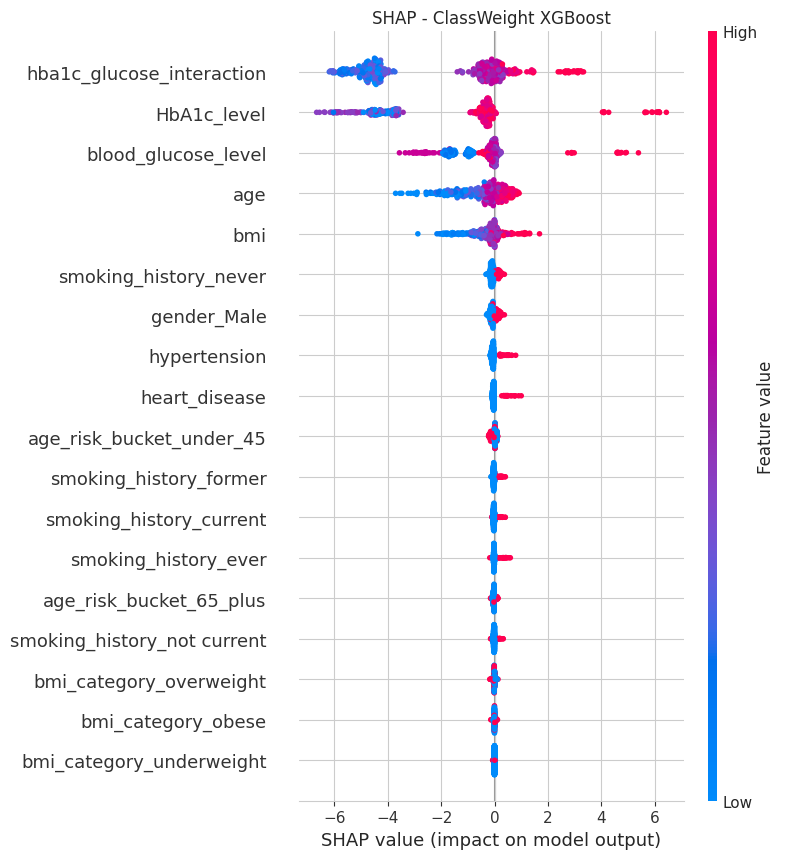


SHAP - Best SMOTE model


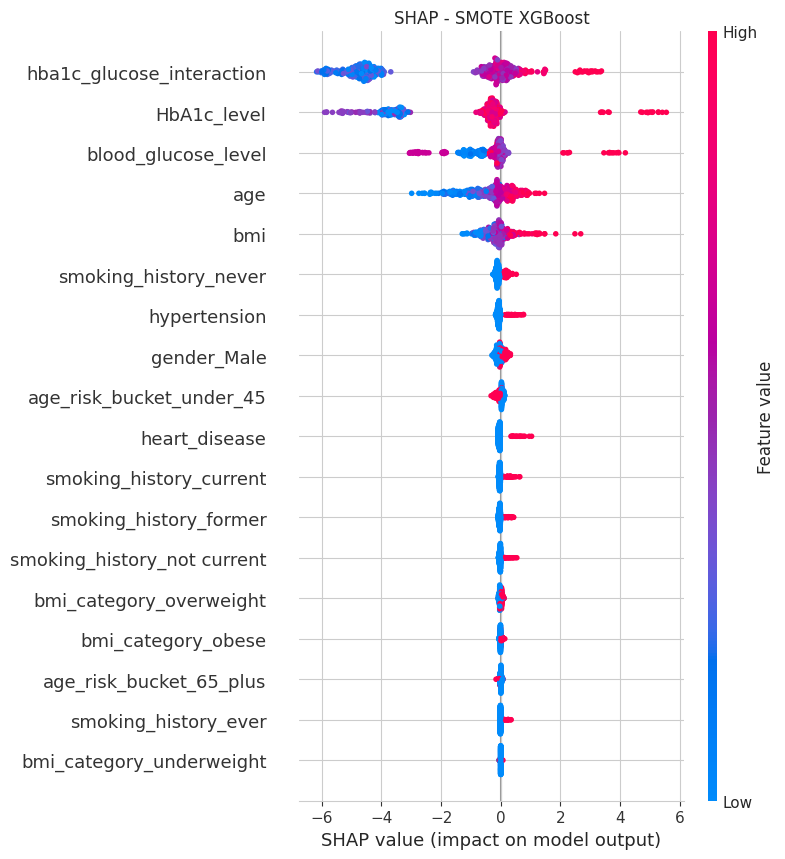


SHAP - Best Undersample model


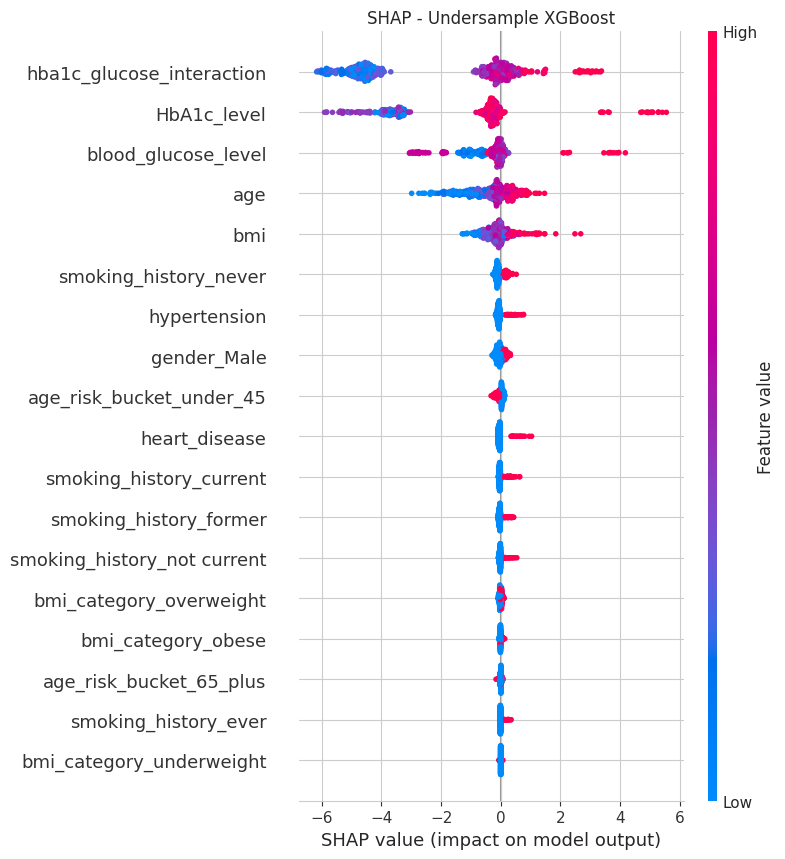

(<shap.explainers._tree.TreeExplainer at 0x7d7e1ccdd010>,
 array([[ 0.20912579, -0.0291612 , -0.01217537, ..., -0.2643575 ,
         -0.05742049, -0.26143503],
        [ 0.04008877, -0.03558532, -0.01360359, ..., -3.4301784 ,
         -0.08116982, -4.3074684 ],
        [-0.18433204, -0.01913526, -0.00782546, ..., -0.24236502,
         -0.20048286, -0.0780912 ],
        ...,
        [-0.07637742, -0.04603291, -0.00601263, ..., -0.34481862,
         -1.1609229 , -5.1810493 ],
        [-0.03764215, -0.02885086, -0.02949787, ..., -0.17817532,
         -1.3018911 , -5.99714   ],
        [ 0.0330556 , -0.03514342, -0.00977059, ..., -3.6813068 ,
         -0.04485753, -4.442743  ]], dtype=float32),
 array([[ 1.        ,  0.        ,  0.        , ...,  0.1551329 ,
          0.53244645,  0.4478694 ],
        [ 1.        ,  0.        ,  0.        , ..., -1.89590193,
         -0.29921859, -1.06241406],
        [ 0.        ,  0.        ,  0.        , ...,  0.52804833,
          0.41014276,  0.55528

In [ ]:
# We take the best model according to AUPRC for each technique
best_baseline = max(baseline_results.items(), key=lambda x: x[1]['auprc'])
best_weighted = max(weighted_results.items(), key=lambda x: x[1]['auprc'])
best_smote    = max(smote_results.items(), key=lambda x: x[1]['auprc'])
best_undersample = max(undersample_results.items(), key=lambda x: x[1]['auprc'])

print("Best models by AUPRC:")
print(f"Baseline    -> {best_baseline[0]} ({best_baseline[1]['auprc']:.4f})")
print(f"ClassWeight -> {best_weighted[0]} ({best_weighted[1]['auprc']:.4f})")
print(f"SMOTE       -> {best_smote[0]} ({best_smote[1]['auprc']:.4f})")
print(f"Undersample -> {best_undersample[0]} ({best_undersample[1]['auprc']:.4f})")

def shap_summary(pipeline, X_sample, title):
    # Raw X_sample must go through feature_engineering before the preprocessor, since
    # every pipeline now starts with that step (bmi_category, age_risk_bucket, and the
    # HbA1c x glucose interaction term don't exist on the raw columns).
    X_engineered = pipeline.named_steps['feature_engineering'].transform(X_sample)
    X_transformed = pipeline.named_steps['preprocessor'].transform(X_engineered)

    # Feature names after one-hot
    cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = list(cat_features) + numerical_features

    # Choose explainer based on model type
    model = pipeline.named_steps['classifier']

    if isinstance(model, (RandomForestClassifier, XGBClassifier)):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_transformed)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    else:
        explainer = shap.LinearExplainer(model, X_transformed)
        shap_values = explainer.shap_values(X_transformed)

    plt.figure()
    shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return explainer, shap_values, X_transformed, feature_names

# Use a sample of the test set for speed
X_sample = X_test.sample(500, random_state=42)

print("\nSHAP - Best Baseline model")
shap_summary(best_baseline[1]['pipeline'], X_sample, f"SHAP - Baseline {best_baseline[0]}")

print("\nSHAP - Best Class-Weight model")
shap_summary(best_weighted[1]['pipeline'], X_sample, f"SHAP - ClassWeight {best_weighted[0]}")

print("\nSHAP - Best SMOTE model")
shap_summary(best_smote[1]['pipeline'], X_sample, f"SHAP - SMOTE {best_smote[0]}")

print("\nSHAP - Best Undersample model")
shap_summary(best_undersample[1]['pipeline'], X_sample, f"SHAP - Undersample {best_undersample[0]}")

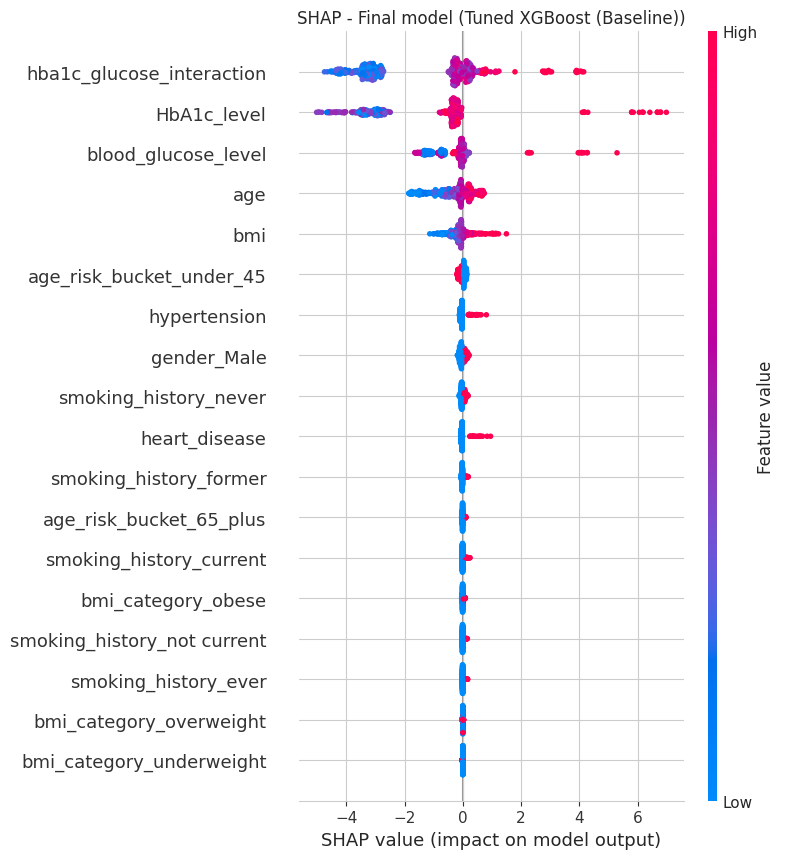

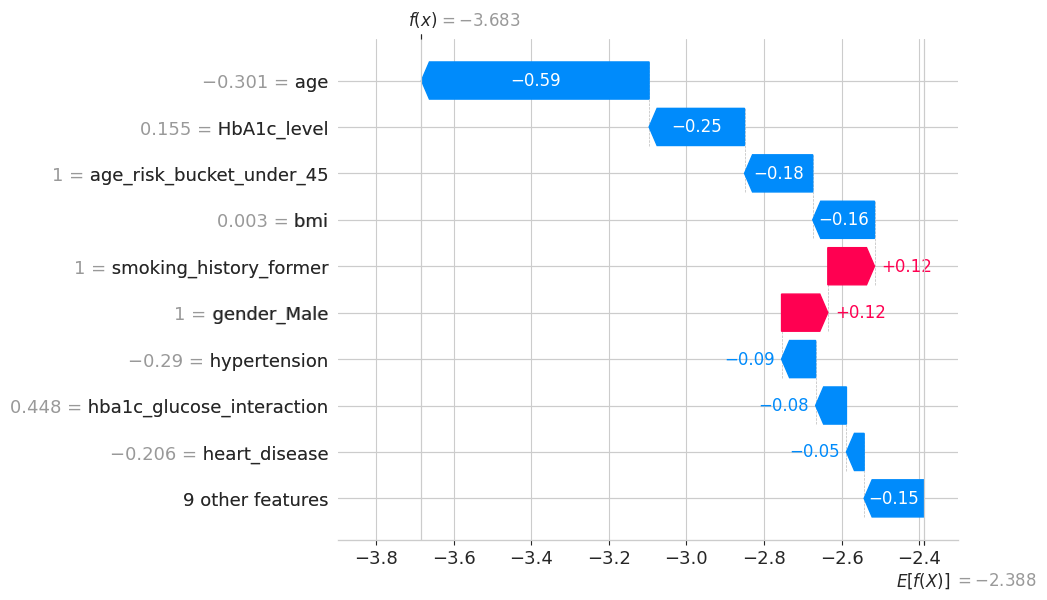

In [ ]:
# Individual prediction explanation for the FINAL selected model (one specific patient),
# using the modern, stable shap.Explanation + shap.plots.waterfall API.
explainer, shap_values, X_transformed, feature_names = shap_summary(
    final_pipeline, X_sample, f"SHAP - Final model ({final_choice})"
)

instance_idx = 0
base_value = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)
explanation = shap.Explanation(
    values=shap_values[instance_idx],
    base_values=base_value,
    data=X_transformed[instance_idx] if hasattr(X_transformed, '__getitem__') else X_transformed.iloc[instance_idx].values,
    feature_names=list(feature_names),
)
shap.plots.waterfall(explanation)

# Final Comparison vs Existing Work

Our final model against the three works reviewed in the Milestone 2 report: mezkymy's
tuned Random Forest, and the Kaggle-author's MLflow PySpark pipeline. This is the
explicit contrast the Milestone 4 rubric's Contributions & Originality criterion grades
on directly — not just better numbers, but a clear, honest comparison against prior work
including where we do and don't improve on it.

In [ ]:
print("=== Final Comparison ===")
print(f"{'Source':<38}{'Accuracy':>10}{'ROC-AUC':>10}{'Diabetic Precision':>20}{'Diabetic Recall':>18}")
print(f"{'mezkymy (tuned Random Forest)':<38}{'n/a':>10}{'n/a':>10}{'low (~1/3)':>20}{'~95%':>18}")
print(f"{'Kaggle MLflow pipeline':<38}{96.11:>9.2f}%{0.811:>10.3f}{'n/a':>20}{'n/a':>18}")
print(f"{'Our final model (' + final_choice + ')':<38}"
      f"{final_metrics['accuracy']*100:>9.2f}%{final_metrics['roc_auc']:>10.4f}"
      f"{final_metrics['precision']*100:>19.2f}%{final_metrics['recall']*100:>17.2f}%")
print()
print("Notes for the report:")
print("- Kaggle MLflow's 96.11% accuracy is easy to over-read: a trivial 'always predict")
print("  no diabetes' classifier already scores ~91.5% given the class imbalance, and")
print("  that notebook reports no diabetic-class precision/recall at all.")
print("- mezkymy's Random Forest optimized almost entirely for recall (~95%) at the cost")
print("  of precision (author's own words: 'noticeably low', ~1 in 3 flagged patients")
print("  actually diabetic) -- recommended only as a coarse pre-screen, not standalone.")
print("- Our model is the only one of the four compared here (mezkymy, Kaggle MLflow, and")
print("  our own baseline/tuned candidates) with cross-validated hyperparameter tuning,")
print("  three imbalance-handling techniques compared head-to-head, engineered features,")
print("  and both global and individual-level SHAP interpretability.")

=== Final Comparison ===
Source                                  Accuracy   ROC-AUC  Diabetic Precision   Diabetic Recall
mezkymy (tuned Random Forest)                n/a       n/a          low (~1/3)              ~95%
Kaggle MLflow pipeline                    96.11%     0.811                 n/a               n/a
Our final model (Tuned XGBoost (Baseline))    97.17%    0.9768              98.08%            69.22%

Notes for the report:
- Kaggle MLflow's 96.11% accuracy is easy to over-read: a trivial 'always predict
  no diabetes' classifier already scores ~91.5% given the class imbalance, and
  that notebook reports no diabetic-class precision/recall at all.
- mezkymy's Random Forest optimized almost entirely for recall (~95%) at the cost
  of precision (author's own words: 'noticeably low', ~1 in 3 flagged patients
  actually diabetic) -- recommended only as a coarse pre-screen, not standalone.
- Our model is the only one of the four compared here (mezkymy, Kaggle MLflow, and
  our o